In [1]:
%matplotlib inline

# Автоматическое дифференцирование в Pytorch
 
`torch.autograd`
=======================================

При обучении нейронных сетей наиболее часто используемым алгоритмом является
**обратное распространение ошибки** (back propagation). В этом алгоритме параметры (веса модели)
корректируются в соответствии с **градиентом** функции потерь относительно
заданного параметра.

Для вычисления этих градиентов в PyTorch есть встроенный механизм дифференцирования
под названием `torch.autograd`. Он поддерживает автоматическое вычисление градиента для любого
вычислительного графика.

Рассмотрим простейшую однослойную нейронную сеть с входными данными `x`,
параметрами `w` и `b` и некоторой функцией потерь. 
В PyTorch это можно сделать  следующим образом:


In [2]:
import torch

x = torch.ones(5)  # входной тензор 
y = torch.zeros(3)  # выходное значение
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

Вычислительный граф
------------------------------------------


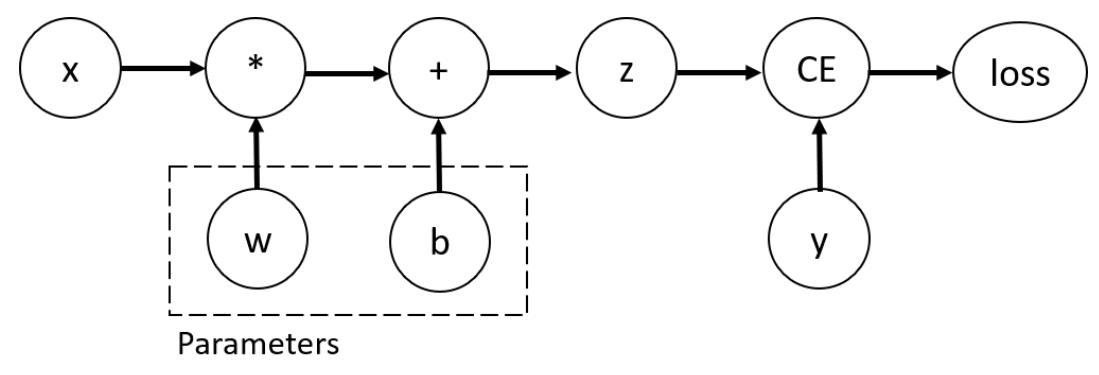


В нашей  сети `w` и `b` являются **обучаемыми параметрами** (parameters), которые нам нужно
найти. Для этого нам нужно вычислять градиенты
функции потерь относительно этих переменных. Для чего  мы устанавливаем
свойство `requires_grad` для этих тензоров (установить значение `requires_grad` можно при создании тензора
или позже, используя метод `x.requires_grad_(True)`)


Функция, которую мы применяем к тензорам для построения вычислительного графа
, на самом деле является объектом класса `Function`. Этот объект знает, как
вычислить функцию в прямом направлении, а также как вычислить
ее производную на этапе обратного распространения. Ссылка на
функцию обратного распространения хранится в свойстве тензора `grad_fn`. (подробнее в документации <https://pytorch.org/docs/stable/autograd.html#function>`.)




In [3]:
print('Gradient function for z =', z.grad_fn)
print('Gradient function for loss =', loss.grad_fn)

Gradient function for z = <AddBackward0 object at 0x10717d250>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x10717df70>


Вычисление градиентов
-------------------

Чтобы оптимизировать веса параметров в нейронной сети, нам нужно
вычислить производные нашей функции потерь по параметрам (веса и смещения),
а именно, нам нужны $\frac {\partial loss}{\partial w}$ и
$\frac{\partial loss}{\partial b}$ при некоторых фиксированных значениях
`x` и `y`. Чтобы вычислить эти производные, мы вызываем
`loss.backward()`, а затем извлекаем значения из `w.grad` и
`b.grad`.:

In [4]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.0175, 0.0104, 0.0228],
        [0.0175, 0.0104, 0.0228],
        [0.0175, 0.0104, 0.0228],
        [0.0175, 0.0104, 0.0228],
        [0.0175, 0.0104, 0.0228]])
tensor([0.0175, 0.0104, 0.0228])


<h4>Примечание</h4> - Мы можем получить значения `grad` только для конечных
узлов вычислительного графа, которые имеют свойство `requires_grad`= `True`. Для всех остальных узлов нашего графа градиенты будут
недоступны.
  - Мы можем выполнять вычисления градиента, используя ``backward`` только один раз на данном графе, по соображениям производительности. Если нам нужно выполнить несколько ``backward`` вызовов для одного и того же графа, нам нужно передать
    `retain_graph=True` для  вызова ``backward``.




Отключение отслеживания градиента
---------------------------

По умолчанию все тензоры с `requires_grad=True` отслеживают
историю своих вычислений и поддерживают вычисление градиента. Однако есть
некоторые случаи, когда нам не нужно этого делать, например, когда мы
обучили модель и просто хотим применить ее к некоторым входным данным, т.е. мы
хотим только выполнять *прямые* (*forward*) вычисления по сети. Мы можем прекратить
отслеживание вычислений, поместив наш вычислительный код в блок
`torch.no_grad()`:



In [5]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

True
False


Другой способ достичь того же результата - использовать метод `detach()
` для тензора:

In [6]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

False



Есть причины, по которым вы, возможно, захотите отключить отслеживание градиента:
  - Чтобы пометить некоторые параметры в вашей нейронной сети как **замороженные параметры** (frozen parameters). Это
очень распространенный сценарий для 
    `тонкой настройки предварительно обученной сети (finetuning) <https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html>`__
  - Чтобы ** ускорить вычисления **, когда вы выполняете только прямой проход (forward pass), в этом случае вычисления на тензорах
будут более эффективными.


  Подробнее о вычислительных графах
----------------------------
Концептуально autograd хранит запись данных (тензоров) и всех выполненных
операций (вместе с результирующими новыми тензорами) в ориентированном ациклическом
графе (DAG), состоящем из
объектов `Function <https://pytorch.org/docs/stable/autograd.html#torch.autograd.Function>
. В этом DAG листья являются входными тензорами, корни - выходными
тензорами. Прослеживая этот граф от корней к листьям, вы можете
автоматически вычислять градиенты, используя правило цепочки.

При прямом проходе autograd выполняет две задачи одновременно:

- запускает запрошенную операцию для вычисления результирующего тензора
- сохраняет функцию градиента операции в DAG.

Обратный проход начинается, когда вызывается `.backward()`  в корне DAG
. затем ``autograd``:

- вычисляет градиенты из каждого `.grad_fn`,
- накапливает их в атрибуте соответствующего тензора `.grad`
- используя правило цепочки, распространяется вплоть до конечных тензоров.

<h4>Примечание</h4> 
**DAGs являются динамическими в PyTorch**
  Важно отметить, что граф воссоздается с нуля; после каждого
  вызова `.backward()` автоград начинает заполнять новый граф. Это
 позволяет  использовать инструкции потока управления в вашей модели;
  при необходимости  можно изменять форму, размер и операции на каждой итерации
.</p></div>



Тензорные градиенты и произведения Якобиана
--------------------------------------

Во многих случаях у нас есть скалярная функция потерь, и нам нужно вычислить
градиент относительно некоторых параметров. Однако бывают случаи, когда выходной функцией является произвольный тензор. 
В этом случае PyTorch позволяет вычислять так называемое **якобианово произведение**, а не фактический
градиент.

Для векторной функции $\vec{y}=f(\vec{x})$, где
$\vec{x}=\langle x_1,\dots,x_n\rangle$ и
$\vec{y}=\langle y_1,\dots,y_m\rangle$, задан градиент
$\vec{y}$ относительно $\vec{x}$ на основе **матрицы Якобиана**:


\begin{align}J=\left(\begin{array}{ccc}
      \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
      \vdots & \ddots & \vdots\\
      \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
      \end{array}\right)\end{align}

Вместо вычисления самой матрицы Якоби, PyTorch позволяет вычислить **Произведение Якоби** $v ^ T \ cdot J$ для заданного входного вектора
$v=(v_1 \dots v_m)$ с помощью вызова`backward` с
$v$ в качестве аргумента. Размер $v$ должен быть таким же, как
размер исходного тензора, относительно которого мы хотим
вычислить произведение:

In [7]:
inp = torch.eye(5, requires_grad=True)
out = (inp+1).pow(2)
out.backward(torch.ones_like(inp), retain_graph=True)
print("First call\n", inp.grad)
out.backward(torch.ones_like(inp), retain_graph=True)
print("\nSecond call\n", inp.grad)
inp.grad.zero_()
out.backward(torch.ones_like(inp), retain_graph=True)
print("\nCall after zeroing gradients\n", inp.grad)

First call
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.],
        [2., 2., 2., 2., 4.]])

Second call
 tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.],
        [4., 4., 4., 4., 8.]])

Call after zeroing gradients
 tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.],
        [2., 2., 2., 2., 4.]])


Обратите внимание, что когда мы вызываем ``backward`` во второй раз с тем же
аргументом, значение градиента отличается. Это происходит потому
, что при выполнении `обратного распространения` PyTorch ** накапливает
градиенты**, т.е. значение вычисленных градиентов добавляется к свойству
`grad` всех конечных узлов вычислительного графа. Если вы хотите
вычислить правильные градиенты, вам нужно предварительно обнулить значение в `grad`
. Для этого используется **optimizer.zero_grad()**.


<h4>Примечание</h4> Ранее мы вызывали функцию `backward()` без
          параметров. Это, по сути, эквивалентно вызову
          ``backward(torch.tensor(1.0))``, что является удобным способом вычисления
градиентов в случае скалярнозначной функции, такой как потеря во время
          обучения нейронной сети.</p> 


--------------




Подробнее о `Autograd`
<https://pytorch.org/docs/stable/notes/autograd.html>`_

